In [1]:
from rtrv_models.MazeExplorer.agent import CA3BeliefAgent, retrieve_with_latents, train_belief_agent, retrieval_mismatch_demo
import numpy as np

if __name__ == "__main__":
    from rtrv_models.MazeExplorer.graph import MazeEnv, maze1_graph

    # Example trajectory nodes (start fixed at node 1)
    train_nodes_m1 = np.array([1,13,14,26,27,15,3,4,5,6,18,17,29,30,31,19,20,21,9,10,11,12,24,23,22,34,33,32,44,45,46,47,48,60,59,58,57,56,68,69,70,71,72,84,83,95,94,82,81,80,92,104,103,91,90,78,79,67,55,54,66,65,64,63,75,74,62,50,51,39,38,37,49,61,73,85,97,109,110,122,123,111,112,100,99,87,88,76,77,89,101,102,114,113,125,124,136,137,138,126,127,115,116,117,129,141,142,130,131,132,144],dtype = np.int64)
    maze1 = MazeEnv(graph=maze1_graph, start_node=1, goal_node=144)
    train_ego_m1 = maze1.to_ego_actions(train_nodes_m1)
    
    train_nodes_m2 = np.array([1,2,14,13,25,37,49,61,73,74,86,85,97,98,110,109,121,133,134,135,123,111,99,100,88,76,75,63,64,65,53,52,40,28,29,17,5,6,7,19,18,30,31,43,44,32,33,21,9,10,11,12,24,23,22,34,46,45,57,69,68,67,55,54,66,78,77,89,101,102,114,115,116,104,103,91,79,80,92,93,105,106,94,82,70,71,59,60,72,84,83,95,96,108,120,119,131,130,142,143,144], dtype = np.int64)
    train_ego_m2 = maze1.to_ego_actions(train_nodes_m2)
    
    train_nodes = np.concatenate([train_nodes_m1, train_nodes_m2+144])
    train_ego = np.concatenate([train_ego_m1, train_ego_m2])
    
    retrv_nodes = np.array([99,87,88,76,77,89,101,102,114,113,125,124,136,137,138,126,127,115,116,117,129,141,142,130,131,132,144], np.int64)
    retrv_ego = maze1.to_ego_actions(retrv_nodes)

    model = CA3BeliefAgent(token_embed_dim=32, ca3_hidden_dim=128, n_cues=1)


    # Train on a tiny dataset
    train_belief_agent(model, ego_dataset=[train_ego]*50, node_dataset=[train_nodes]*50, epochs=200, batch_size=128)

epoch 001 | loss=5.665309
epoch 002 | loss=5.638132
epoch 003 | loss=5.611484
epoch 004 | loss=5.584725
epoch 005 | loss=5.557290
epoch 006 | loss=5.528658
epoch 007 | loss=5.498371
epoch 008 | loss=5.466039
epoch 009 | loss=5.431331
epoch 010 | loss=5.393970
epoch 011 | loss=5.353737
epoch 012 | loss=5.310556
epoch 013 | loss=5.264469
epoch 014 | loss=5.215633
epoch 015 | loss=5.164347
epoch 016 | loss=5.110923
epoch 017 | loss=5.055521
epoch 018 | loss=4.998187
epoch 019 | loss=4.938673
epoch 020 | loss=4.876818
epoch 021 | loss=4.812654
epoch 022 | loss=4.746426
epoch 023 | loss=4.678475
epoch 024 | loss=4.609178
epoch 025 | loss=4.539021
epoch 026 | loss=4.468189
epoch 027 | loss=4.396946
epoch 028 | loss=4.325365
epoch 029 | loss=4.253547
epoch 030 | loss=4.181552
epoch 031 | loss=4.109474
epoch 032 | loss=4.037224
epoch 033 | loss=3.964915
epoch 034 | loss=3.892628
epoch 035 | loss=3.820546
epoch 036 | loss=3.748807
epoch 037 | loss=3.677686
epoch 038 | loss=3.607291
epoch 039 | 

In [3]:
belief, h_seq, hT = retrieve_with_latents(model, retrv_ego, cue_id=0)
belief2, h_seq2, hT2 = retrieve_with_latents(model, train_ego_m1, cue_id=0)

corr = np.zeros(h_seq.shape[0])
for t in range(h_seq.shape[0]):
    corr[t] = np.corrcoef(h_seq[t, :], h_seq2[t-27, :])[0,1]

import matplotlib.pyplot as plt


# Normal cue (cue_id=0)
print("\nNormal cue (cue_id=0):")
retrieval_mismatch_demo(model, train_ego, train_nodes, cue_id_test=0)

# Mismatched cue (cue_id=1) -- this is your "wrong initialization" handle
print("\nMismatched cue (cue_id=1):")
retrieval_mismatch_demo(model, retrv_ego, retrv_nodes, cue_id_test=0)


Normal cue (cue_id=0):
time | MAP_node | true_node | p(true)
   0 |        1 |         1 | 0.963
  23 |       23 |        23 | 0.936
  46 |       94 |        94 | 0.946
  70 |       38 |        38 | 0.942
  93 |      113 |       113 | 0.951
 117 |      193 |       193 | 0.927
 140 |      209 |       209 | 0.967
 164 |      167 |       167 | 0.912
 187 |      223 |       223 | 0.930
 211 |      288 |       288 | 0.971

mean p(true) = 0.942
final p(true) = 0.971

Mismatched cue (cue_id=1):
time | MAP_node | true_node | p(true)
   0 |        1 |        99 | 0.000
   2 |       26 |        88 | 0.011
   5 |       89 |        89 | 0.584
   8 |       87 |       114 | 0.025
  11 |       26 |       124 | 0.051
  14 |      138 |       138 | 0.777
  17 |      115 |       115 | 0.826
  20 |      129 |       129 | 0.917
  23 |      130 |       130 | 0.956
  26 |      144 |       144 | 0.963

mean p(true) = 0.488
final p(true) = 0.963


In [4]:
model_2 = CA3BeliefAgent(token_embed_dim=32, ca3_hidden_dim=128, n_cues=1)


node_1 = np.array([1, 2, 3, 4, 5, 6, 7]) 
ego_1 = np.array([-1,0, 0, 0, 0, 0,1])
node_2 = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) 
ego_2 = np.array([2, 3, 3, 3, 3,3,3,3,3,6])

nodes = np.concatenate([node_1, node_2])
egos = np.concatenate([ego_1, ego_2])

train_belief_agent(model_2, ego_dataset=[egos]*50, node_dataset=[nodes]*50, epochs=200, batch_size=128)


epoch 001 | loss=5.709723
epoch 002 | loss=5.628727
epoch 003 | loss=5.547010
epoch 004 | loss=5.462989
epoch 005 | loss=5.374967
epoch 006 | loss=5.281173
epoch 007 | loss=5.179553
epoch 008 | loss=5.068181
epoch 009 | loss=4.944774
epoch 010 | loss=4.807403
epoch 011 | loss=4.654225
epoch 012 | loss=4.483953
epoch 013 | loss=4.296598
epoch 014 | loss=4.093759
epoch 015 | loss=3.880109
epoch 016 | loss=3.662816
epoch 017 | loss=3.452097
epoch 018 | loss=3.257986
epoch 019 | loss=3.088348
epoch 020 | loss=2.945328
epoch 021 | loss=2.826243
epoch 022 | loss=2.725713
epoch 023 | loss=2.639183
epoch 024 | loss=2.563841
epoch 025 | loss=2.497769
epoch 026 | loss=2.439738
epoch 027 | loss=2.388495
epoch 028 | loss=2.342863
epoch 029 | loss=2.301555
epoch 030 | loss=2.263529
epoch 031 | loss=2.227956
epoch 032 | loss=2.194159
epoch 033 | loss=2.161699
epoch 034 | loss=2.129950
epoch 035 | loss=2.098495
epoch 036 | loss=2.067044
epoch 037 | loss=2.035332
epoch 038 | loss=2.003324
epoch 039 | 

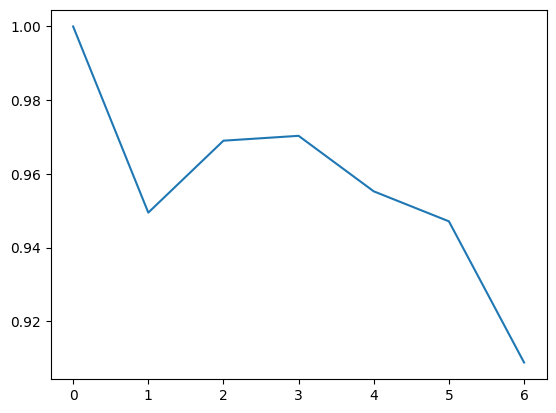

In [9]:
belief, h_seq, hT = retrieve_with_latents(model_2, ego_1, cue_id=0)
belief2, h_seq2, hT2 = retrieve_with_latents(model_2, ego_2, cue_id=0)

corr = np.zeros(7)
for t in range(7):
    corr[t] = np.corrcoef(h_seq[t, :], h_seq2[t, :])[0,1]

import matplotlib.pyplot as plt
plt.plot(corr)